In [1]:
from fleet_replacement.episode import EpisodeRecord, EpisodeRecorder
from fleet_replacement.envs.fleet_replacement import FleetReplacementEnv
from fleet_replacement.policies import LookaheadAgent
from fleet_replacement.config import load_env_config

config = load_env_config("../configs/env.yaml")
env = EpisodeRecorder(FleetReplacementEnv(config=config))
agent = LookaheadAgent(config)

obs, _ = env.reset(seed=42)
while True:
    obs, reward, terminated, truncated, info = env.step(agent.select_action(obs))
    if terminated or truncated:
        break

record = env.episode_record
df = record.to_dataframe()  # pandas DataFrame, indexed by year
record.save("../results/ep42.pkl")  # persist

# For visualisation:
record.years  # (35,)
record.n_electric  # (35,)
record.actions  # (35, 10)  — heatmap of decisions per slot
record.reward_component("revenue")  # (35,)

c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\comm

array([31200000.        , 31200000.        , 31200000.        ,
       31200000.        , 31200000.        , 31200000.        ,
       31200000.        , 31200000.        , 30668720.02130345,
       29474809.05578667, 29078052.09981893, 29114194.94453082,
       29117853.48175737, 29314198.30180416, 29438752.41785634,
       29516476.39868998, 29564480.87017586, 29593941.49426324,
       29611951.02284861, 29622934.06943733])

In [2]:
df.head()

,n_electric,n_diesel,avg_age,energy_price_diesel,energy_price_electricity,purchase_price_DT,purchase_price_BET,productivity_BET,reward,revenue,diesel_cost,electricity_cost,salary_cost,interest_cost,depreciation_cost,sale_result,capex,opex,total_reward
year,,,,,,,,,,,,,,,,,,,
2026,0,8,3.5,18.000000,3.000000,1600000.0,3200000.00,0.708517,15372800.0,31200000.0,1.123200e+07,0.0,3200000.0,307200.0,1920000.0,832000.0,2227200.0,1.443200e+07,15372800.0
2027,0,8,3.5,17.803091,3.088947,1600000.0,2974056.50,0.713716,15495671.0,31200000.0,1.110913e+07,0.0,3200000.0,307200.0,1920000.0,832000.0,2227200.0,1.430913e+07,15495671.0
2028,0,8,3.5,17.290400,2.929826,1600000.0,2712029.25,0.721803,15815591.0,31200000.0,1.078921e+07,0.0,3200000.0,307200.0,1920000.0,832000.0,2227200.0,1.398921e+07,15815591.0
2029,0,8,3.5,17.350590,2.925517,1600000.0,2404319.00,0.733972,15778032.0,31200000.0,1.082677e+07,0.0,3200000.0,307200.0,1920000.0,832000.0,2227200.0,1.402677e+07,15778032.0
2030,0,8,3.5,17.832355,3.015552,1600000.0,2250058.25,0.751402,15477411.0,31200000.0,1.112739e+07,0.0,3200000.0,307200.0,1920000.0,832000.0,2227200.0,1.432739e+07,15477411.0


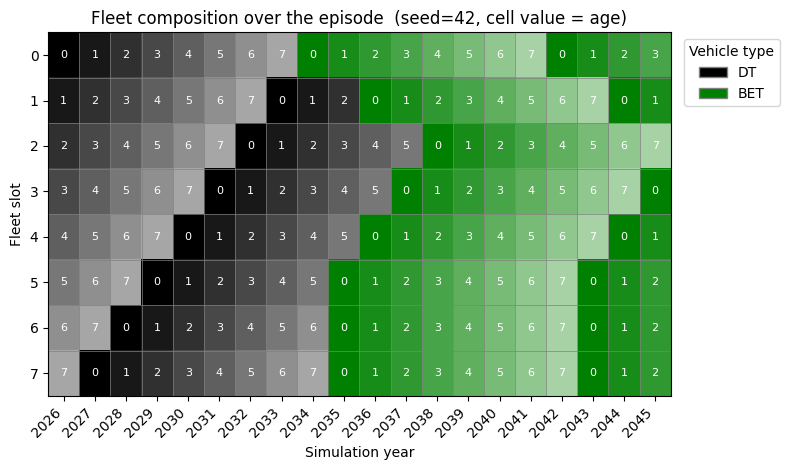

In [3]:
from plot_helpers import plot_episode_fleet_composition

plot_episode_fleet_composition(record)

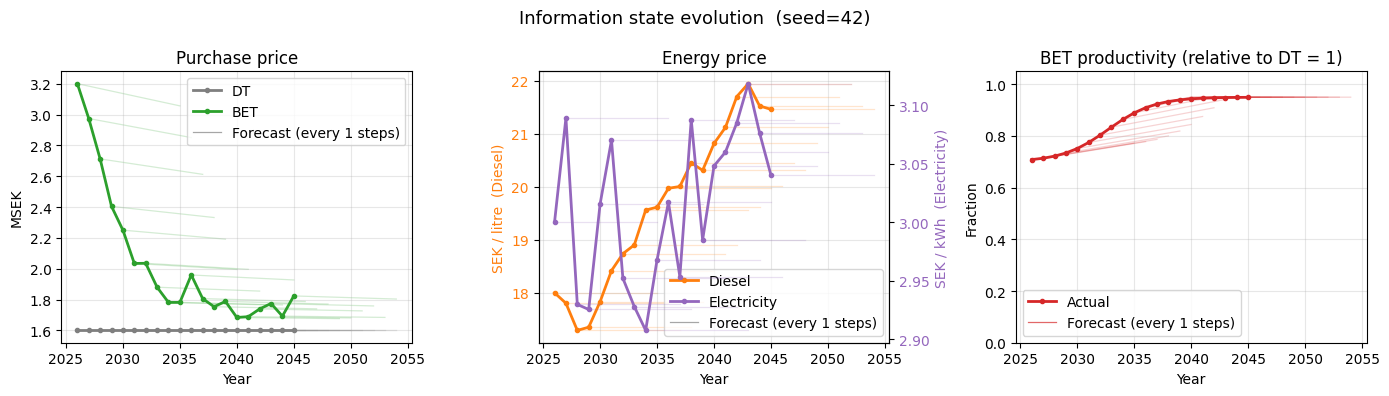

In [4]:
from plot_helpers import plot_episode_information_state

plot_episode_information_state(record, agent)

In [5]:
record.reward_component("sale_result")

array([ 832000.        ,  832000.        ,  832000.        ,
        832000.        ,  832000.        ,  832000.        ,
        832000.        ,  832000.        , 2688000.        ,
       1152000.        ,  960000.        ,  960000.        ,
             0.        ,       0.        ,       0.        ,
        878203.96148793, 2712799.94996266, 1845280.5904848 ,
        880052.90347011,  948179.19265217])